In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# For time-based split later
from sklearn.model_selection import TimeSeriesSplit

In [10]:
# Step 1: Load the raw ball-by-ball data
df = pd.read_csv('ipl_cleaned_data.csv')

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nTarget-related distribution (batsman_runs):")
print(df['batsman_runs'].describe())
print("\nUnique seasons:", df['season'].nunique())
print("\nUnique venues:", df['venue'].nunique())
print("\nSample dates range:", df['date'].min(), "to", df['date'].max())

Dataset shape: (104094, 20)

Columns: ['matchid', 'inning', 'over', 'ball', 'batting_team', 'bowling_team', 'batsman', 'bowler', 'batsman_runs', 'extras', 'total_runs', 'iswide', 'isnoball', 'player_dismissed', 'season', 'date', 'venue', 'team1', 'team2', 'winner']

First few rows:
   matchid  inning  over  ball           batting_team  \
0   335982       1     0     1  Kolkata Knight Riders   
1   335982       1     0     2  Kolkata Knight Riders   
2   335982       1     0     3  Kolkata Knight Riders   
3   335982       1     0     4  Kolkata Knight Riders   
4   335982       1     0     5  Kolkata Knight Riders   

                  bowling_team      batsman   bowler  batsman_runs  extras  \
0  Royal Challengers Bangalore   SC Ganguly  P Kumar             0       1   
1  Royal Challengers Bangalore  BB McCullum  P Kumar             0       0   
2  Royal Challengers Bangalore  BB McCullum  P Kumar             0       1   
3  Royal Challengers Bangalore  BB McCullum  P Kumar          

In [11]:
# Step 2: Aggregate to batsman per innings (matchid + inning as unique match-innings)
# Valid balls for balls_faced: exclude wides/noballs
df['is_valid_ball'] = ((df['iswide'] == 0) & (df['isnoball'] == 0)).astype(int)

# Group by matchid, inning, batsman for core stats
batsman_innings = df[df['is_valid_ball'] == 1].groupby(['matchid', 'inning', 'batsman']).agg({
    'batsman_runs': 'sum',
    'ball': 'count'  # Number of valid balls faced
}).rename(columns={
    'batsman_runs': 'runs_scored',
    'ball': 'balls_faced'
}).reset_index()

# Merge back match-level info (teams, venue, etc.) - drop duplicates for unique key
match_info = df[['matchid', 'inning', 'batsman', 'batting_team', 'bowling_team',
                 'date', 'venue', 'season', 'team1', 'team2', 'winner']].drop_duplicates(
                     subset=['matchid', 'inning', 'batsman'])

batsman_innings = batsman_innings.merge(match_info, on=['matchid', 'inning', 'batsman'], how='left')

# Compute current innings strike rate (for potential feature, but we'll use historical)
batsman_innings['strike_rate'] = np.where(
    batsman_innings['balls_faced'] > 0,
    (batsman_innings['runs_scored'] / batsman_innings['balls_faced']) * 100,
    0
)

print("Batsman-innings shape:", batsman_innings.shape)
print("\nSample aggregated data:")
print(batsman_innings.head())
print("\nRuns scored distribution:")
print(batsman_innings['runs_scored'].describe())

Batsman-innings shape: (6604, 14)

Sample aggregated data:
   matchid  inning          batsman  runs_scored  balls_faced  \
0   335982       1      BB McCullum          158           73   
1   335982       1        DJ Hussey           12           12   
2   335982       1  Mohammad Hafeez            5            3   
3   335982       1       RT Ponting           20           20   
4   335982       1       SC Ganguly           10           12   

            batting_team                 bowling_team        date  \
0  Kolkata Knight Riders  Royal Challengers Bangalore  2008-04-18   
1  Kolkata Knight Riders  Royal Challengers Bangalore  2008-04-18   
2  Kolkata Knight Riders  Royal Challengers Bangalore  2008-04-18   
3  Kolkata Knight Riders  Royal Challengers Bangalore  2008-04-18   
4  Kolkata Knight Riders  Royal Challengers Bangalore  2008-04-18   

                   venue   season                        team1  \
0  M Chinnaswamy Stadium  2007/08  Royal Challengers Bangalore   
1  

In [12]:
# Step 3: Sort by date for historical computations (convert date to datetime)
batsman_innings['date'] = pd.to_datetime(batsman_innings['date'])
batsman_innings = batsman_innings.sort_values(['batsman', 'date']).reset_index(drop=True)

# Historical cumulative stats per batsman
batsman_innings['cum_runs'] = batsman_innings.groupby('batsman')['runs_scored'].cumsum()
batsman_innings['cum_balls'] = batsman_innings.groupby('batsman')['balls_faced'].cumsum()
batsman_innings['innings_played'] = batsman_innings.groupby('batsman').cumcount() + 1

# Historical avg runs (mean of all previous innings)
batsman_innings['batsman_avg'] = batsman_innings.groupby('batsman')['runs_scored'].transform(
    lambda x: x.shift(1).expanding().mean().fillna(0)
)

# Historical avg balls faced
batsman_innings['balls_faced_avg'] = batsman_innings.groupby('batsman')['balls_faced'].transform(
    lambda x: x.shift(1).expanding().mean().fillna(0)
)

# Historical strike rate (cumulative up to previous)
batsman_innings['historical_sr'] = np.where(
    batsman_innings['cum_balls'].shift(1) > 0,
    (batsman_innings['cum_runs'].shift(1) / batsman_innings['cum_balls'].shift(1)) * 100,
    0
)

print("Sample with historical features:")
print(batsman_innings[['batsman', 'date', 'runs_scored', 'batsman_avg', 'historical_sr', 'balls_faced_avg']].head(10))

Sample with historical features:
          batsman       date  runs_scored  batsman_avg  historical_sr  \
0  A Ashish Reddy 2012-04-29           10     0.000000       0.000000   
1  A Ashish Reddy 2012-05-04            3    10.000000     100.000000   
2  A Ashish Reddy 2012-05-08            8     6.500000     100.000000   
3  A Ashish Reddy 2012-05-18           10     7.000000     100.000000   
4  A Ashish Reddy 2012-05-20            4     7.750000     124.000000   
5  A Ashish Reddy 2013-04-05            7     7.000000     120.689655   
6  A Ashish Reddy 2013-04-07           14     7.000000     127.272727   
7  A Ashish Reddy 2013-04-09            3     8.000000     124.444444   
8  A Ashish Reddy 2013-04-12           16     7.375000     120.408163   
9  A Ashish Reddy 2013-04-14            4     8.333333     129.310345   

   balls_faced_avg  
0         0.000000  
1        10.000000  
2         6.500000  
3         7.000000  
4         6.250000  
5         5.800000  
6         5.5000

In [15]:
# Step 4: Historical avg vs specific opposition (bowling_team)
# Sort by batsman, bowling_team, date
temp_df = batsman_innings.sort_values(['batsman', 'bowling_team', 'date'])

# Avg vs opp (previous matches vs this team) - with fallback
temp_df['avg_vs_opp'] = temp_df.groupby(['batsman', 'bowling_team'])['runs_scored'].transform(
    lambda x: x.shift(1).expanding().mean()
).fillna(
    temp_df.groupby('batsman')['runs_scored'].transform(
        lambda y: y.shift(1).expanding().mean().fillna(0)  # Fallback to overall hist avg
    )
)

batsman_innings = temp_df.sort_values(['batsman', 'date']).reset_index(drop=True)

# Opposition strength: Historical avg runs conceded by bowling_team (per innings) - FIXED MERGE
# Compute total runs per innings
innings_totals = df.groupby(['matchid', 'inning'])['total_runs'].sum().reset_index(name='innings_total_runs')

# Merge bowling_team and date (ensure unique per innings)
team_date_df = df[['matchid', 'inning', 'bowling_team', 'date']].drop_duplicates(subset=['matchid', 'inning'])
innings_totals = innings_totals.merge(team_date_df, on=['matchid', 'inning'], how='left')

# Cast to ensure int keys (fix dtype mismatch)
innings_totals['matchid'] = innings_totals['matchid'].astype(int)
innings_totals['inning'] = innings_totals['inning'].astype(int)  # Key fix here
innings_totals['date'] = pd.to_datetime(innings_totals['date'])
innings_totals = innings_totals.sort_values(['bowling_team', 'date']).reset_index(drop=True)

# Historical avg conceded (cum mean up to previous) - with fallback
innings_totals['opp_strength'] = innings_totals.groupby('bowling_team')['innings_total_runs'].transform(
    lambda x: x.shift(1).expanding().mean().fillna(innings_totals['innings_total_runs'].mean())
)

# Cast keys in batsman_innings too
batsman_innings['matchid'] = batsman_innings['matchid'].astype(int)
batsman_innings['inning'] = batsman_innings['inning'].astype(int)

# Merge to batsman_innings - now with matching dtypes
pre_merge_len = len(batsman_innings)
batsman_innings = batsman_innings.merge(
    innings_totals[['matchid', 'inning', 'opp_strength']],
    on=['matchid', 'inning'], how='left'
)
post_merge_len = len(batsman_innings)

# Fallback if any NaNs after merge (rare, but safety)
batsman_innings['opp_strength'] = batsman_innings['opp_strength'].fillna(innings_totals['innings_total_runs'].mean())

print(f"Merge success: {pre_merge_len} -> {post_merge_len} rows, NaNs in opp_strength after fill: {batsman_innings['opp_strength'].isna().sum()}")

# Home advantage: Assume team1 is home team
batsman_innings['home_advantage'] = (batsman_innings['batting_team'] == batsman_innings['team1']).astype(int)

# Season trend: Extract year from season (from previous fix)
batsman_innings['season'] = batsman_innings['season'].fillna('0')
batsman_innings['season_year'] = (
    batsman_innings['season'].str.split('/').str[0]
    .str.strip()
    .pipe(pd.to_numeric, errors='coerce')
    .astype('Int64')
)

# Venue encoded
le = LabelEncoder()
batsman_innings['venue_encoded'] = le.fit_transform(batsman_innings['venue'].fillna('Unknown'))

print("Features added. Sample:")
print(batsman_innings[['batsman', 'bowling_team', 'avg_vs_opp', 'opp_strength', 'home_advantage', 'season_year', 'venue_encoded']].head())
print(f"\nSeason_year stats: Min={batsman_innings['season_year'].min()}, Max={batsman_innings['season_year'].max()}, NaNs={batsman_innings['season_year'].isna().sum()}")

Merge success: 6604 -> 6604 rows, NaNs in opp_strength after fill: 0
Features added. Sample:
          batsman                 bowling_team  avg_vs_opp  opp_strength  \
0  A Ashish Reddy               Mumbai Indians   11.285714    145.955224   
1  A Ashish Reddy          Chennai Super Kings    0.000000    148.444444   
2  A Ashish Reddy              Kings XI Punjab   15.000000    153.115942   
3  A Ashish Reddy             Rajasthan Royals   11.500000    145.971831   
4  A Ashish Reddy  Royal Challengers Bangalore   11.583333    156.802632   

   home_advantage  season_year  venue_encoded  
0               0         <NA>             32  
1               0         <NA>             15  
2               1         <NA>             22  
3               1         <NA>             22  
4               1         <NA>             22  

Season_year stats: Min=2007, Max=2012, NaNs=2411


In [16]:
# Step 5: Select features and target (drop rows with low innings_played if needed, e.g., >5 for stability)
# Filter to batsmen with at least 5 previous innings for reliable historical features
filtered_df = batsman_innings[batsman_innings['innings_played'] > 5].copy()

feature_cols = [
    'batsman_avg', 'historical_sr', 'balls_faced_avg', 'avg_vs_opp',
    'venue_encoded', 'opp_strength', 'home_advantage', 'season_year'
]
X = filtered_df[feature_cols]
y = filtered_df['runs_scored']

# Handle any remaining NaNs (rare after fillna)
X = X.fillna(X.median())

print("Filtered dataset shape:", filtered_df.shape)
print("Features shape:", X.shape)
print("\nFeature stats:")
print(X.describe())

Filtered dataset shape: (5090, 27)
Features shape: (5090, 8)

Feature stats:
       batsman_avg  historical_sr  balls_faced_avg   avg_vs_opp  \
count  5090.000000    5090.000000      5090.000000  5090.000000   
mean     20.886553     125.400831        16.357284    20.517288   
std       8.608464      20.551768         6.070230    14.445121   
min       0.428571      23.529412         1.400000     0.000000   
25%      15.651293     115.117278        12.631313     9.750000   
50%      21.446360     124.926361        16.943651    19.250000   
75%      26.483737     136.515181        20.461285    28.000000   
max      59.100000     206.250000        43.400000   158.000000   

       venue_encoded  opp_strength  home_advantage  season_year  
count    5090.000000   5090.000000     5090.000000       5090.0  
mean       17.187230    148.503038        0.495874  2009.446562  
std         8.761356      8.035243        0.500032     1.194897  
min         0.000000     83.000000        0.000000     

In [17]:
# Step 6: Time-based split (80% early data for train, 20% recent for test)
# Sort by date
filtered_df_sorted = filtered_df.sort_values('date').reset_index(drop=True)
split_idx = int(0.8 * len(filtered_df_sorted))
X_train = filtered_df_sorted.iloc[:split_idx][feature_cols]
y_train = filtered_df_sorted.iloc[:split_idx]['runs_scored']
X_test = filtered_df_sorted.iloc[split_idx:][feature_cols]
y_test = filtered_df_sorted.iloc[split_idx:]['runs_scored']

print(f"Training set size: {X_train.shape[0]} (up to {filtered_df_sorted.iloc[split_idx-1]['date'].date()})")
print(f"Test set size: {X_test.shape[0]} (from {filtered_df_sorted.iloc[split_idx]['date'].date()})")

Training set size: 4072 (up to 2013-04-29)
Test set size: 1018 (from 2013-04-29)


In [18]:
# Step 7: Baseline - Mean Predictor
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

print("\n=== BASELINE MODEL (Mean Predictor) ===")
print(f"MSE: {baseline_mse:.4f}")
print(f"MAE: {baseline_mae:.4f}")
print(f"R²: {baseline_r2:.4f}")


=== BASELINE MODEL (Mean Predictor) ===
MSE: 408.6690
MAE: 15.8576
R²: -0.0001


In [19]:
# Step 8: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

# Time-series CV (use TimeSeriesSplit for realism)
tscv = TimeSeriesSplit(n_splits=5)
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=tscv, scoring='r2')

print("\n=== RANDOM FOREST MODEL ===")
print(f"Test MSE: {rf_mse:.4f}")
print(f"Test MAE: {rf_mae:.4f}")
print(f"Test R²: {rf_r2:.4f}")
print(f"CV R² (mean ± std): {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

# Feature importance
importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nTop Features by Importance:")
print(importances)


=== RANDOM FOREST MODEL ===
Test MSE: 389.8900
Test MAE: 15.2398
Test R²: 0.0459
CV R² (mean ± std): 0.0167 ± 0.0328

Top Features by Importance:
           feature  importance
0      batsman_avg    0.208409
2  balls_faced_avg    0.173528
5     opp_strength    0.161634
3       avg_vs_opp    0.158365
1    historical_sr    0.149209
4    venue_encoded    0.084448
7      season_year    0.046582
6   home_advantage    0.017825


In [20]:
# Step 9: XGBoost
xgb_model = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

# CV with TimeSeriesSplit
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=tscv, scoring='r2')

print("\n=== XGBOOST MODEL ===")
print(f"Test MSE: {xgb_mse:.4f}")
print(f"Test MAE: {xgb_mae:.4f}")
print(f"Test R²: {xgb_r2:.4f}")
print(f"CV R² (mean ± std): {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}")


=== XGBOOST MODEL ===
Test MSE: 455.7890
Test MAE: 16.2539
Test R²: -0.1154
CV R² (mean ± std): -0.1691 ± 0.0651


In [21]:
# Step 10: Comparison Table
models = ['Baseline', 'Random Forest', 'XGBoost']
mse_scores = [baseline_mse, rf_mse, xgb_mse]
mae_scores = [baseline_mae, rf_mae, xgb_mae]
r2_scores = [baseline_r2, rf_r2, xgb_r2]

comparison_df = pd.DataFrame({
    'Model': models,
    'MSE': mse_scores,
    'MAE': mae_scores,
    'R²': r2_scores
})
print("\n=== MODEL COMPARISON ===")
print(comparison_df.round(4))


=== MODEL COMPARISON ===
           Model      MSE      MAE      R²
0       Baseline  408.669  15.8576 -0.0001
1  Random Forest  389.890  15.2398  0.0459
2        XGBoost  455.789  16.2539 -0.1154


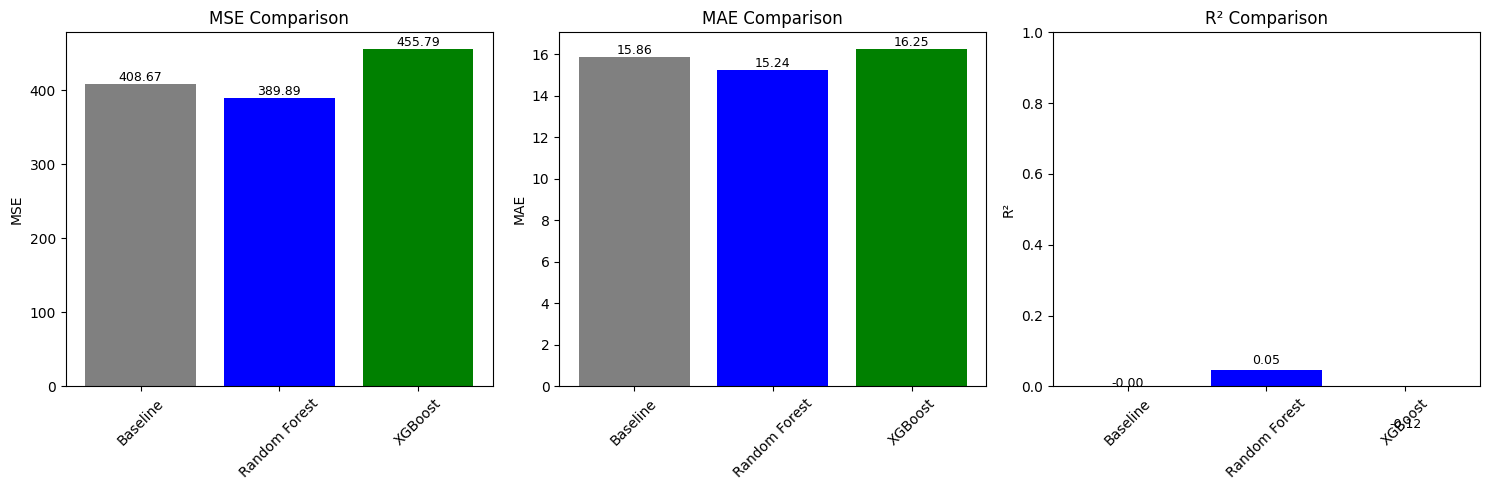

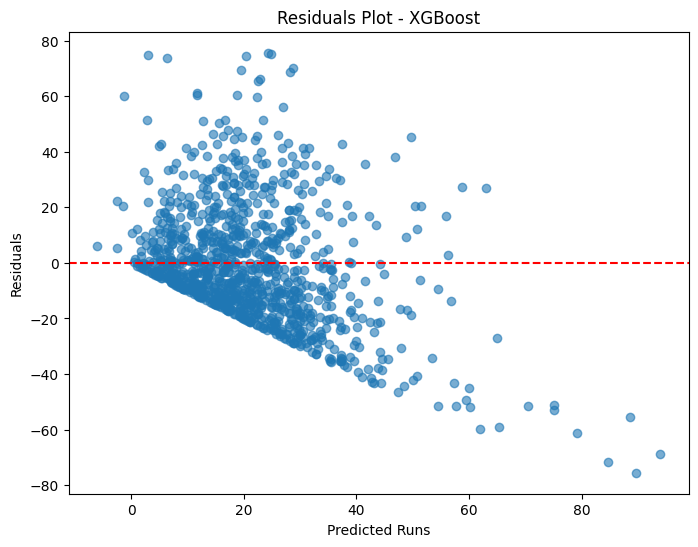

In [23]:
# Step 11: Visualize Comparison and Residuals
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Map metrics to exact column names (fix case sensitivity)
col_map = {'MSE': 'MSE', 'MAE': 'MAE', 'R²': 'R²'}

for i, metric in enumerate(['MSE', 'MAE', 'R²']):
    col_name = col_map[metric]
    scores = comparison_df[col_name].values  # Exact column access
    axes[i].bar(models, scores, color=['gray', 'blue', 'green'])
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)  # Rotate labels for readability
    # Add value labels on bars
    for j, score in enumerate(scores):
        axes[i].text(j, score + (0.01 * np.sign(score) if score < 0 else 0.01), f'{score:.2f}',
                     ha='center', va='bottom', fontsize=9)
    if metric == 'R²':
        axes[i].set_ylim(0, max(1, max(comparison_df['R²']) + 0.05))  # Slight padding

plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

# Residuals for best model (XGBoost assuming it wins; swap to rf_pred if RF better)
best_pred = xgb_pred
residuals = y_test - best_pred
plt.figure(figsize=(8, 6))
plt.scatter(best_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Runs')
plt.ylabel('Residuals')
plt.title('Residuals Plot - XGBoost')
plt.savefig('residuals_plot.png')
plt.show()

In [24]:
# Step 12: Save processed data and models
filtered_df.to_csv('processed_player_data.csv', index=False)
import joblib
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(le, 'venue_encoder.pkl')  # For future use
print("\nProcessed data and models saved.")

# Notes:
# - Time-based split prevents leakage; adjust split ratio if needed.
# - Tune models with GridSearchCV on n_estimators, max_depth for better perf.
# - If data is too large, sample or use Dask for scaling.
# - Validate: R² >0 indicates beating baseline; aim for >0.1-0.2 in sports preds.


Processed data and models saved.
